confidence interval:  1.9166287881556527 3.045866027943761
ConfidenceInterval(low=np.float64(1.9072726754969846), high=np.float64(3.019695738779504))


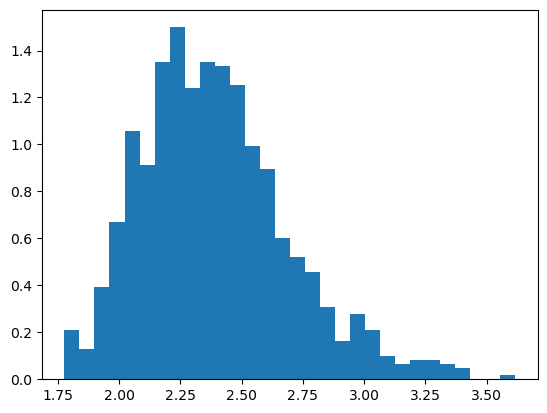

In [5]:
import numpy as np
from scipy.stats import skewnorm, bootstrap
import matplotlib.pyplot as plt

n=100

x=skewnorm.rvs(a=1,size=n,random_state=42)                  ##

def kurtosis(y):
    mu=np.mean(y)
    sigma=np.sqrt(np.var(y))

    data=[]
    for i in range(len(y)):
        point=((y[i]-mu)/sigma)**4
        data.append(point)

    return np.mean(data)

def boot_strap(y):
    B=1000
    boot_kurt=[]
    for i in range(B):
        xb=np.random.choice(y,size=n,replace=True)                            ##
        boot_kurt.append(kurtosis(xb))                                        ##

    return np.array(boot_kurt)


plt.hist(boot_strap(x),bins=30,density=True)

lower=np.percentile(boot_strap(x),2.5)                                       ##
upper=np.percentile(boot_strap(x),97.5)

print("confidence interval: ",lower,upper)

res = bootstrap(                                                ##
    (x,),
    statistic=lambda y: kurtosis(y),
    confidence_level=0.95,
    n_resamples=1000,
    method='percentile',
    random_state=42
)

print(res.confidence_interval)

In [17]:
import numpy as np
from scipy.stats import skewnorm, bootstrap
import matplotlib.pyplot as plt

n=100

x=skewnorm.rvs(a=1,size=n,random_state=42)                  ##

def kurtosis(y):
    mu=np.mean(y)
    sigma=np.sqrt(np.var(y))

    data=[]
    for i in range(len(y)):
        point=((y[i]-mu)/sigma)**4
        data.append(point)

    return np.mean(data)

def boot_strap(y):
    B=1000
    boot_kurt=[]
    for i in range(B):
        xb=np.random.choice(y,size=n,replace=True)                            ##
        boot_kurt.append(kurtosis(xb))                                        ##

    return np.array(boot_kurt)


plt.hist(boot_strap(x),bins=30,density=True)

lower=np.percentile(boot_strap(x),2.5)                                       ##
upper=np.percentile(boot_strap(x),97.5)

print("confidence interval: ",lower,upper)

res = bootstrap(                                                ##
    (x,),
    statistic=lambda y: kurtosis(y),
    confidence_level=0.95,
    n_resamples=1000,
    method='percentile',
    random_state=42
)

print(res.confidence_interval)



#----------------------4a---------------------#

if lower <= kurtosis(x) <= upper:
    print("kurtosis lies in CI")
else:
    print("kurtosis doesn't lie in CI")

# Monte Carlo null distribution under Gaussian H0
B = 1000
null_kurt = []

for _ in range(B):
    sample = np.random.normal(0,1,n)               ##
    null_kurt.append(kurtosis(sample))

null_kurt = np.array(null_kurt)

# Gaussian kurtosis target = 3                        ##
target = 3

dist_obs = abs(kurtosis(x) - target)                      ##
dist_null = abs(null_kurt - target)                   ##

pval = (np.sum(dist_null >= dist_obs) + 1) / (B + 1)    ##

print("Manual p-value =", pval)

from scipy.stats import monte_carlo_test

p_val = monte_carlo_test(                                   ##
    x,
    rvs=lambda size: np.random.normal(0,1,size),
    statistic=kurtosis,
    n_resamples=1000
)

print("Scipy p-value =", p_val.pvalue)

#----------------------4b---------------------#



kurtosis lies in CI
Manual p-value = 0.14385614385614387
Scipy p-value = 0.18181818181818182
